In [89]:
#code to create unique occupied states plot
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde
from matplotlib.gridspec import GridSpec
from sklearn.metrics import roc_curve, auc

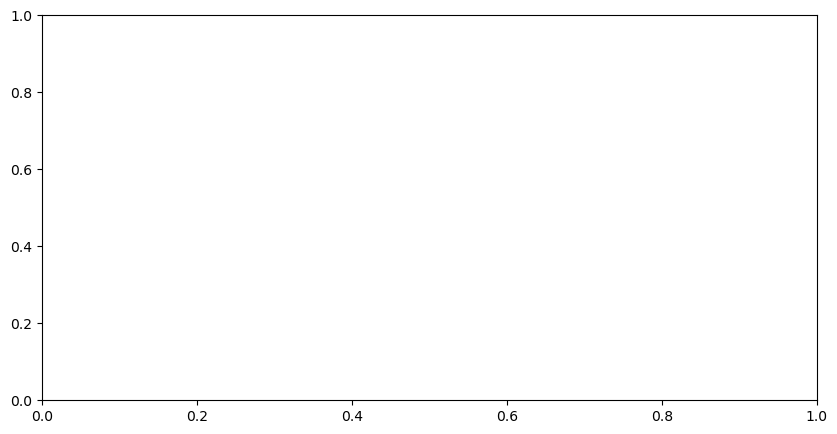

In [90]:
fig_roc, ax_roc = plt.subplots(figsize=(10, 5))

/tmp/ipykernel_416291/2020981115.py:47: RuntimeWarning: divide by zero encountered in divide
  ax[1].plot(tpr, 1/fpr,
/tmp/ipykernel_416291/2020981115.py:57: RuntimeWarning: divide by zero encountered in divide
  ax_roc.plot(tpr, 1/fpr,
/tmp/ipykernel_416291/2020981115.py:47: RuntimeWarning: divide by zero encountered in divide
  ax[1].plot(tpr, 1/fpr,
/tmp/ipykernel_416291/2020981115.py:57: RuntimeWarning: divide by zero encountered in divide
  ax_roc.plot(tpr, 1/fpr,
/tmp/ipykernel_416291/2020981115.py:47: RuntimeWarning: divide by zero encountered in divide
  ax[1].plot(tpr, 1/fpr,
/tmp/ipykernel_416291/2020981115.py:57: RuntimeWarning: divide by zero encountered in divide
  ax_roc.plot(tpr, 1/fpr,
/tmp/ipykernel_416291/2020981115.py:47: RuntimeWarning: divide by zero encountered in divide
  ax[1].plot(tpr, 1/fpr,
/tmp/ipykernel_416291/2020981115.py:57: RuntimeWarning: divide by zero encountered in divide
  ax_roc.plot(tpr, 1/fpr,


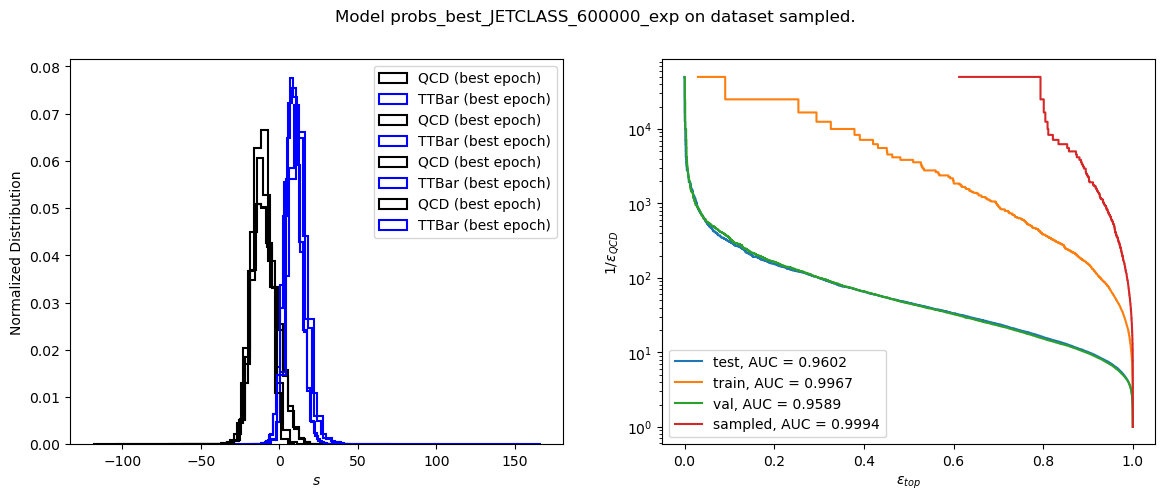

In [91]:
# creates s distributions and roc score for notified tag
DATASET = "JETCLASS"
TAGS = ["test", "train", "val", "sampled"]

folder = f"probs_best_{DATASET}_600000_exp"

classes = ["QCD", "TTBar"]
colors = ["black", "blue"]
       
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

bins = 60

for tag in TAGS:
    scores = np.array([])
    labels = np.array([])

    for i in range(len(classes)):
        top_vs_i = pd.read_csv(f"../output/plot_data/{folder}/{classes[1]}_{classes[i]}_{tag}.csv")
        qcd_vs_i = pd.read_csv(f"../output/plot_data/{folder}/{classes[0]}_{classes[i]}_{tag}.csv")

        s_i = top_vs_i - qcd_vs_i

        bins = 30

        # normalized histogram (area = 1), step style
        ax[0].hist(
            s_i["probs"],
            bins=bins,                 # adjust for smoothness
            density=True,            # normalization
            histtype="step",
            linewidth=1.5,
            linestyle="-",
            color=colors[i],
            label=f"{classes[i]} (best epoch)"
        )
        scores_i = s_i["probs"].to_numpy()

        #compute roc curve for each input mode and 
        scores = np.append(scores, scores_i)
        labels = np.append(labels, np.full(len(scores_i), i))

    fpr, tpr, thresholds = roc_curve(labels, scores)

    roc_auc = auc(fpr, tpr)

    ax[1].plot(tpr, 1/fpr, 
        label = f"{tag}, AUC = {roc_auc:.4f}")

    ax[1].set_yscale("log")

    ax[1].set_xlabel(r"$\epsilon_{top}$")
    ax[1].set_ylabel(r"$1/\epsilon_{QCD}$")

    ax[1].legend()

    ax_roc.plot(tpr, 1/fpr, 
                label = f"{tag} {folder}, AUC = {roc_auc:.4f}")

    fig.suptitle(f"Model {folder} on dataset {tag}.")

    ax[0].set_ylabel("Normalized Distribution")
    ax[0].set_xlabel(r"$s$")

    #ax.set_xlim(-30, 30)

    ax[0].legend()


/tmp/ipykernel_416291/1857131852.py:46: RuntimeWarning: divide by zero encountered in divide
  ax[1].plot(tpr, 1/fpr,
/tmp/ipykernel_416291/1857131852.py:56: RuntimeWarning: divide by zero encountered in divide
  ax_roc.plot(tpr, 1/fpr,
/tmp/ipykernel_416291/1857131852.py:46: RuntimeWarning: divide by zero encountered in divide
  ax[1].plot(tpr, 1/fpr,
/tmp/ipykernel_416291/1857131852.py:56: RuntimeWarning: divide by zero encountered in divide
  ax_roc.plot(tpr, 1/fpr,
/tmp/ipykernel_416291/1857131852.py:46: RuntimeWarning: divide by zero encountered in divide
  ax[1].plot(tpr, 1/fpr,
/tmp/ipykernel_416291/1857131852.py:56: RuntimeWarning: divide by zero encountered in divide
  ax_roc.plot(tpr, 1/fpr,


/tmp/ipykernel_416291/1857131852.py:46: RuntimeWarning: divide by zero encountered in divide
  ax[1].plot(tpr, 1/fpr,
/tmp/ipykernel_416291/1857131852.py:56: RuntimeWarning: divide by zero encountered in divide
  ax_roc.plot(tpr, 1/fpr,


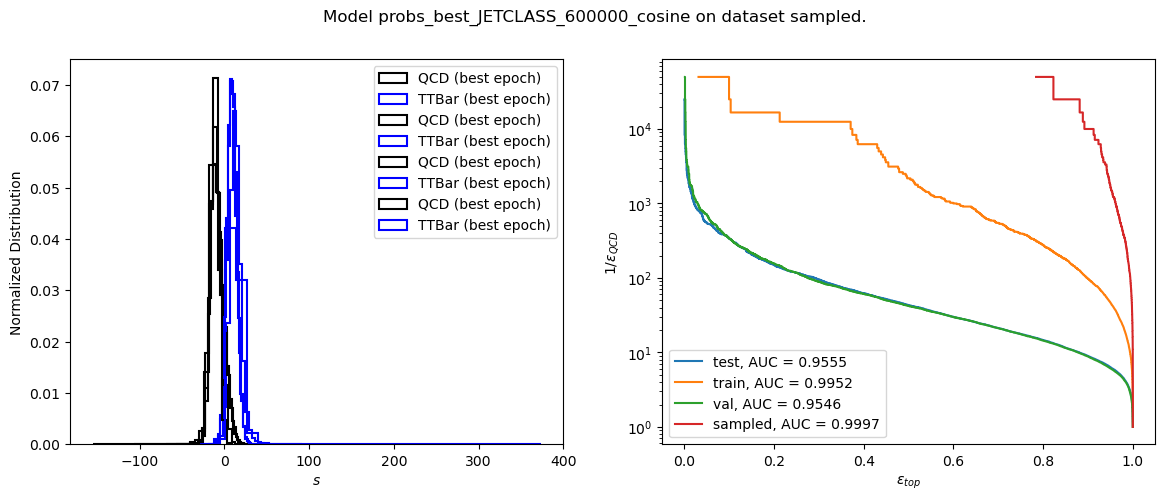

In [92]:
# creates s distributions and roc score for notified tag
DATASET = "JETCLASS"
TAGS = ["test", "train", "val", "sampled"]

folder = f"probs_best_{DATASET}_600000_cosine"

classes = ["QCD", "TTBar"]
colors = ["black", "blue"]
       
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

bins = 60

for tag in TAGS:
    scores = np.array([])
    labels = np.array([])   
    for i in range(len(classes)):
        top_vs_i = pd.read_csv(f"../output/plot_data/{folder}/{classes[1]}_{classes[i]}_{tag}.csv")
        qcd_vs_i = pd.read_csv(f"../output/plot_data/{folder}/{classes[0]}_{classes[i]}_{tag}.csv")

        s_i = top_vs_i - qcd_vs_i

        bins = 30

        # normalized histogram (area = 1), step style
        ax[0].hist(
            s_i["probs"],
            bins=bins,                 # adjust for smoothness
            density=True,            # normalization
            histtype="step",
            linewidth=1.5,
            linestyle="-",
            color=colors[i],
            label=f"{classes[i]} (best epoch)"
        )
        scores_i = s_i["probs"].to_numpy()

        #compute roc curve for each input mode and 
        scores = np.append(scores, scores_i)
        labels = np.append(labels, np.full(len(scores_i), i))

    fpr, tpr, thresholds = roc_curve(labels, scores)

    roc_auc = auc(fpr, tpr)

    ax[1].plot(tpr, 1/fpr, 
        label = f"{tag}, AUC = {roc_auc:.4f}")

    ax[1].set_yscale("log")

    ax[1].set_xlabel(r"$\epsilon_{top}$")
    ax[1].set_ylabel(r"$1/\epsilon_{QCD}$")

    ax[1].legend()

    ax_roc.plot(tpr, 1/fpr, 
                label = f"{tag} {folder}, AUC = {roc_auc:.4f}")

    fig.suptitle(f"Model {folder} on dataset {tag}.")

    ax[0].set_ylabel("Normalized Distribution")
    ax[0].set_xlabel(r"$s$")

    #ax.set_xlim(-30, 30)

    ax[0].legend()


/tmp/ipykernel_416291/2716484482.py:46: RuntimeWarning: divide by zero encountered in divide
  ax[1].plot(tpr, 1/fpr,
/tmp/ipykernel_416291/2716484482.py:56: RuntimeWarning: divide by zero encountered in divide
  ax_roc.plot(tpr, 1/fpr,
/tmp/ipykernel_416291/2716484482.py:46: RuntimeWarning: divide by zero encountered in divide
  ax[1].plot(tpr, 1/fpr,
/tmp/ipykernel_416291/2716484482.py:56: RuntimeWarning: divide by zero encountered in divide
  ax_roc.plot(tpr, 1/fpr,
/tmp/ipykernel_416291/2716484482.py:46: RuntimeWarning: divide by zero encountered in divide
  ax[1].plot(tpr, 1/fpr,
/tmp/ipykernel_416291/2716484482.py:56: RuntimeWarning: divide by zero encountered in divide
  ax_roc.plot(tpr, 1/fpr,
/tmp/ipykernel_416291/2716484482.py:46: RuntimeWarning: divide by zero encountered in divide
  ax[1].plot(tpr, 1/fpr,
/tmp/ipykernel_416291/2716484482.py:56: RuntimeWarning: divide by zero encountered in divide
  ax_roc.plot(tpr, 1/fpr,


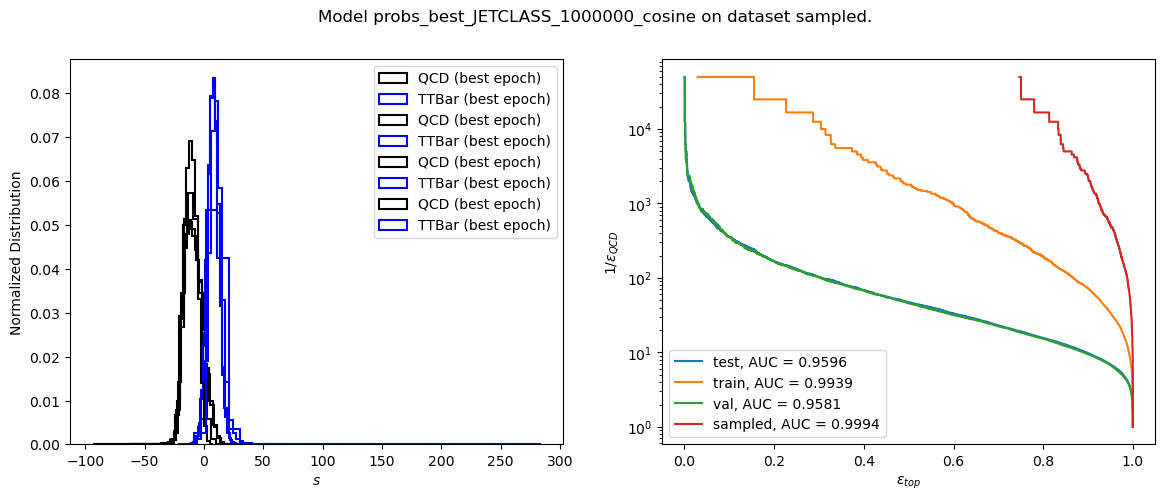

In [93]:
# creates s distributions and roc score for notified tag
DATASET = "JETCLASS"
TAGS = ["test", "train", "val", "sampled"]

folder = f"probs_best_{DATASET}_1000000_cosine"

classes = ["QCD", "TTBar"]
colors = ["black", "blue"]
       
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

bins = 60

for tag in TAGS:
    scores = np.array([])
    labels = np.array([])
    for i in range(len(classes)):
        top_vs_i = pd.read_csv(f"../output/plot_data/{folder}/{classes[1]}_{classes[i]}_{tag}.csv")
        qcd_vs_i = pd.read_csv(f"../output/plot_data/{folder}/{classes[0]}_{classes[i]}_{tag}.csv")

        s_i = top_vs_i - qcd_vs_i

        bins = 30

        # normalized histogram (area = 1), step style
        ax[0].hist(
            s_i["probs"],
            bins=bins,                 # adjust for smoothness
            density=True,            # normalization
            histtype="step",
            linewidth=1.5,
            linestyle="-",
            color=colors[i],
            label=f"{classes[i]} (best epoch)"
        )
        scores_i = s_i["probs"].to_numpy()

        #compute roc curve for each input mode and 
        scores = np.append(scores, scores_i)
        labels = np.append(labels, np.full(len(scores_i), i))

    fpr, tpr, thresholds = roc_curve(labels, scores)

    roc_auc = auc(fpr, tpr)

    ax[1].plot(tpr, 1/fpr, 
        label = f"{tag}, AUC = {roc_auc:.4f}")

    ax[1].set_yscale("log")

    ax[1].set_xlabel(r"$\epsilon_{top}$")
    ax[1].set_ylabel(r"$1/\epsilon_{QCD}$")

    ax[1].legend()

    ax_roc.plot(tpr, 1/fpr, 
                label = f"{tag} {folder}, AUC = {roc_auc:.4f}")

    fig.suptitle(f"Model {folder} on dataset {tag}.")

    ax[0].set_ylabel("Normalized Distribution")
    ax[0].set_xlabel(r"$s$")

    #ax.set_xlim(-30, 30)

    ax[0].legend()


/tmp/ipykernel_416291/990137475.py:47: RuntimeWarning: divide by zero encountered in divide
  ax[1].plot(tpr, 1/fpr,
/tmp/ipykernel_416291/990137475.py:57: RuntimeWarning: divide by zero encountered in divide
  ax_roc.plot(tpr, 1/fpr,
/tmp/ipykernel_416291/990137475.py:47: RuntimeWarning: divide by zero encountered in divide
  ax[1].plot(tpr, 1/fpr,
/tmp/ipykernel_416291/990137475.py:57: RuntimeWarning: divide by zero encountered in divide
  ax_roc.plot(tpr, 1/fpr,
/tmp/ipykernel_416291/990137475.py:47: RuntimeWarning: divide by zero encountered in divide
  ax[1].plot(tpr, 1/fpr,
/tmp/ipykernel_416291/990137475.py:57: RuntimeWarning: divide by zero encountered in divide
  ax_roc.plot(tpr, 1/fpr,


/tmp/ipykernel_416291/990137475.py:47: RuntimeWarning: divide by zero encountered in divide
  ax[1].plot(tpr, 1/fpr,
/tmp/ipykernel_416291/990137475.py:57: RuntimeWarning: divide by zero encountered in divide
  ax_roc.plot(tpr, 1/fpr,


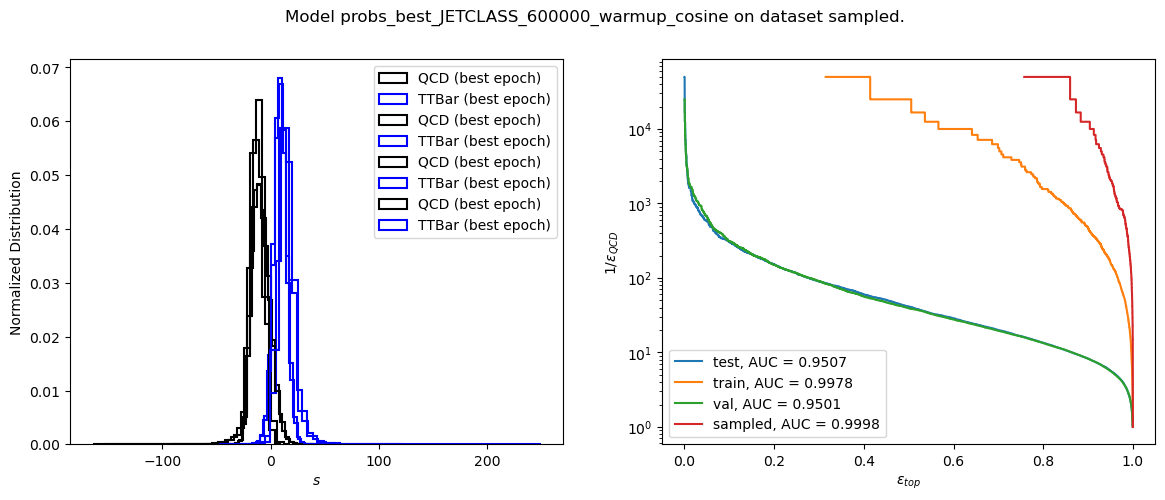

In [94]:
# creates s distributions and roc score for notified tag
DATASET = "JETCLASS"
TAGS = ["test", "train", "val", "sampled"]

folder = f"probs_best_{DATASET}_600000_warmup_cosine"

classes = ["QCD", "TTBar"]
colors = ["black", "blue"]
       
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

bins = 60
for tag in TAGS:

    scores = np.array([])
    labels = np.array([])

    for i in range(len(classes)):
        top_vs_i = pd.read_csv(f"../output/plot_data/{folder}/{classes[1]}_{classes[i]}_{tag}.csv")
        qcd_vs_i = pd.read_csv(f"../output/plot_data/{folder}/{classes[0]}_{classes[i]}_{tag}.csv")

        s_i = top_vs_i - qcd_vs_i

        bins = 30

        # normalized histogram (area = 1), step style
        ax[0].hist(
            s_i["probs"],
            bins=bins,                 # adjust for smoothness
            density=True,            # normalization
            histtype="step",
            linewidth=1.5,
            linestyle="-",
            color=colors[i],
            label=f"{classes[i]} (best epoch)"
        )
        scores_i = s_i["probs"].to_numpy()

        #compute roc curve for each input mode and 
        scores = np.append(scores, scores_i)
        labels = np.append(labels, np.full(len(scores_i), i))

    fpr, tpr, thresholds = roc_curve(labels, scores)

    roc_auc = auc(fpr, tpr)

    ax[1].plot(tpr, 1/fpr, 
        label = f"{tag}, AUC = {roc_auc:.4f}")

    ax[1].set_yscale("log")

    ax[1].set_xlabel(r"$\epsilon_{top}$")
    ax[1].set_ylabel(r"$1/\epsilon_{QCD}$")

    ax[1].legend()

    ax_roc.plot(tpr, 1/fpr, 
                label = f"{tag} {folder}, AUC = {roc_auc:.4f}")

    fig.suptitle(f"Model {folder} on dataset {tag}.")

    ax[0].set_ylabel("Normalized Distribution")
    ax[0].set_xlabel(r"$s$")

    #ax.set_xlim(-30, 30)

    ax[0].legend()


/tmp/ipykernel_416291/3005760039.py:49: RuntimeWarning: divide by zero encountered in divide
  ax[1].plot(tpr, 1/fpr,
/tmp/ipykernel_416291/3005760039.py:59: RuntimeWarning: divide by zero encountered in divide
  ax_roc.plot(tpr, 1/fpr,
/tmp/ipykernel_416291/3005760039.py:49: RuntimeWarning: divide by zero encountered in divide
  ax[1].plot(tpr, 1/fpr,
/tmp/ipykernel_416291/3005760039.py:59: RuntimeWarning: divide by zero encountered in divide
  ax_roc.plot(tpr, 1/fpr,
/tmp/ipykernel_416291/3005760039.py:49: RuntimeWarning: divide by zero encountered in divide
  ax[1].plot(tpr, 1/fpr,
/tmp/ipykernel_416291/3005760039.py:59: RuntimeWarning: divide by zero encountered in divide
  ax_roc.plot(tpr, 1/fpr,


/tmp/ipykernel_416291/3005760039.py:49: RuntimeWarning: divide by zero encountered in divide
  ax[1].plot(tpr, 1/fpr,
/tmp/ipykernel_416291/3005760039.py:59: RuntimeWarning: divide by zero encountered in divide
  ax_roc.plot(tpr, 1/fpr,


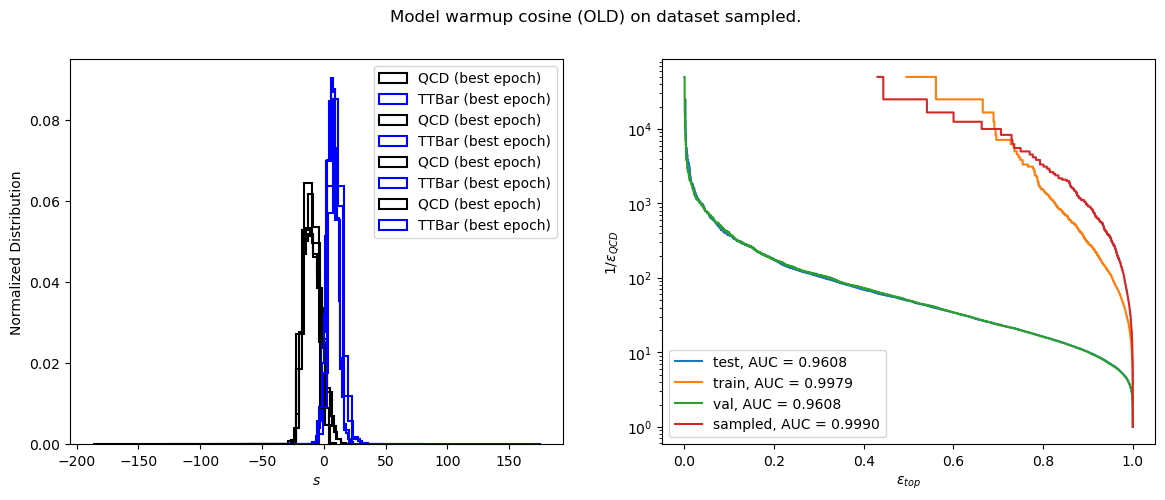

In [95]:
# creates s distributions and roc score for notified tag
DATASET = "JETCLASS"
TAGS = ["test", "train", "val", "sampled"]

classes = ["QCD", "TTBar"]
colors = ["black", "blue"]
       
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

bins = 60

scores = np.array([])
labels = np.array([])

for tag in TAGS:
    scores = np.array([])
    labels = np.array([])

    for i in range(len(classes)):

        top_vs_i = pd.read_csv(f"../output/plot_data_jetclass/probs_best_epoch/{classes[1]}_FACTORIZED_{classes[i]}_{tag}.csv")
        qcd_vs_i = pd.read_csv(f"../output/plot_data_jetclass/probs_best_epoch/{classes[0]}_FACTORIZED_{classes[i]}_{tag}.csv")

        s_i = top_vs_i - qcd_vs_i

        bins = 30

        # normalized histogram (area = 1), step style
        ax[0].hist(
            s_i["probs"],
            bins=bins,                 # adjust for smoothness
            density=True,            # normalization
            histtype="step",
            linewidth=1.5,
            linestyle="-",
            color=colors[i],
            label=f"{classes[i]} (best epoch)"
        )
        scores_i = s_i["probs"].to_numpy()

        #compute roc curve for each input mode and 
        scores = np.append(scores, scores_i)
        labels = np.append(labels, np.full(len(scores_i), i))

    fpr, tpr, thresholds = roc_curve(labels, scores)

    roc_auc = auc(fpr, tpr)

    ax[1].plot(tpr, 1/fpr, 
        label = f"{tag}, AUC = {roc_auc:.4f}")

    ax[1].set_yscale("log")

    ax[1].set_xlabel(r"$\epsilon_{top}$")
    ax[1].set_ylabel(r"$1/\epsilon_{QCD}$")

    ax[1].legend()

    ax_roc.plot(tpr, 1/fpr, 
                label = f"{tag} OLD, AUC = {roc_auc:.4f}")

    fig.suptitle(f"Model warmup cosine (OLD) on dataset {tag}.")

    ax[0].set_ylabel("Normalized Distribution")
    ax[0].set_xlabel(r"$s$")

    #ax.set_xlim(-30, 30)

    ax[0].legend()


/tmp/ipykernel_416291/2081970598.py:48: RuntimeWarning: divide by zero encountered in divide
  ax[1].plot(tpr, 1/fpr,
/tmp/ipykernel_416291/2081970598.py:58: RuntimeWarning: divide by zero encountered in divide
  ax_roc.plot(tpr, 1/fpr,
/tmp/ipykernel_416291/2081970598.py:48: RuntimeWarning: divide by zero encountered in divide
  ax[1].plot(tpr, 1/fpr,
/tmp/ipykernel_416291/2081970598.py:58: RuntimeWarning: divide by zero encountered in divide
  ax_roc.plot(tpr, 1/fpr,
/tmp/ipykernel_416291/2081970598.py:48: RuntimeWarning: divide by zero encountered in divide
  ax[1].plot(tpr, 1/fpr,
/tmp/ipykernel_416291/2081970598.py:58: RuntimeWarning: divide by zero encountered in divide
  ax_roc.plot(tpr, 1/fpr,
/tmp/ipykernel_416291/2081970598.py:48: RuntimeWarning: divide by zero encountered in divide
  ax[1].plot(tpr, 1/fpr,
/tmp/ipykernel_416291/2081970598.py:58: RuntimeWarning: divide by zero encountered in divide
  ax_roc.plot(tpr, 1/fpr,


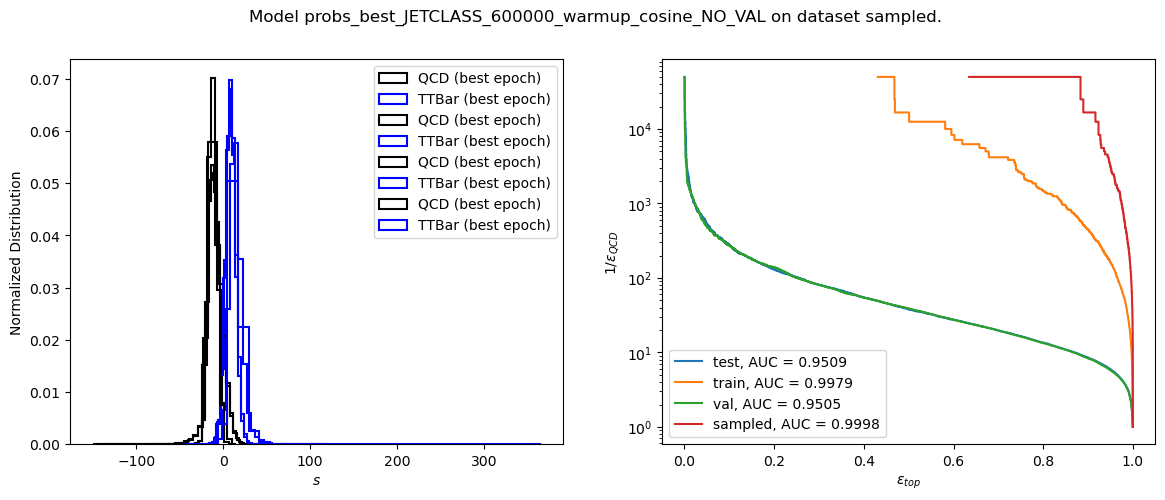

In [96]:
# creates s distributions and roc score for notified tag
DATASET = "JETCLASS"
TAGS = ["test", "train", "val", "sampled"]

folder = f"probs_best_{DATASET}_600000_warmup_cosine_NO_VAL"

classes = ["QCD", "TTBar"]
colors = ["black", "blue"]
       
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

bins = 60


for tag in TAGS:
    scores = np.array([])
    labels = np.array([])

    for i in range(len(classes)):
        top_vs_i = pd.read_csv(f"../output/plot_data/{folder}/{classes[1]}_{classes[i]}_{tag}.csv")
        qcd_vs_i = pd.read_csv(f"../output/plot_data/{folder}/{classes[0]}_{classes[i]}_{tag}.csv")

        s_i = top_vs_i - qcd_vs_i

        bins = 30

        # normalized histogram (area = 1), step style
        ax[0].hist(
            s_i["probs"],
            bins=bins,                 # adjust for smoothness
            density=True,            # normalization
            histtype="step",
            linewidth=1.5,
            linestyle="-",
            color=colors[i],
            label=f"{classes[i]} (best epoch)"
        )
        scores_i = s_i["probs"].to_numpy()

        #compute roc curve for each input mode and 
        scores = np.append(scores, scores_i)
        labels = np.append(labels, np.full(len(scores_i), i))

    fpr, tpr, thresholds = roc_curve(labels, scores)

    roc_auc = auc(fpr, tpr)

    ax[1].plot(tpr, 1/fpr, 
        label = f"{tag}, AUC = {roc_auc:.4f}")

    ax[1].set_yscale("log")

    ax[1].set_xlabel(r"$\epsilon_{top}$")
    ax[1].set_ylabel(r"$1/\epsilon_{QCD}$")

    ax[1].legend()

    ax_roc.plot(tpr, 1/fpr, 
                label = f"{tag} {folder}, AUC = {roc_auc:.4f}")

    fig.suptitle(f"Model {folder} on dataset {tag}.")

    ax[0].set_ylabel("Normalized Distribution")
    ax[0].set_xlabel(r"$s$")

    #ax.set_xlim(-30, 30)

    ax[0].legend()


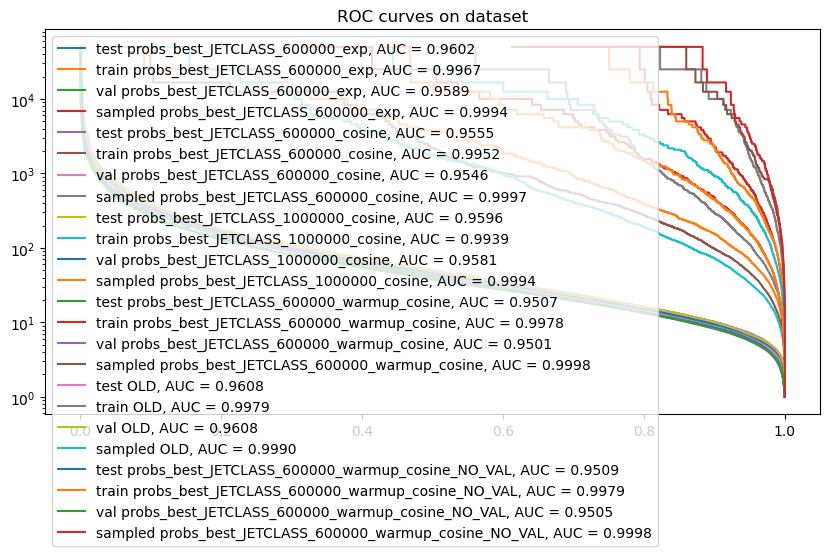

In [97]:
ax_roc.set_title(f"ROC curves on dataset")
ax_roc.legend()
ax_roc.set_yscale("log")

from IPython.display import display
display(fig_roc)